# 🔬 AI-Assisted Breast Cancer Detection — Sprint 1 POC

**Team:** Destroyers | **Subject:** 42174 AI Studio | **Sprint 1 — Week 6**  
**Repo:** https://github.com/Builder-samyak/AI-Studio  
**Dataset:** Breast Histopathology Images (IDC) — paultimothymooney/breast-histopathology-images  
**Environment:** AWS SageMaker / Google Colab (platform-neutral)

---

## Notebook Contents

| # | Section | Description |
|---|---|---|
| 1 | Imports & device setup | All libraries, reproducibility seed |
| 2 | ClearML MLOps setup | Experiment tracking configuration |
| 3 | Dataset download | Kaggle API, platform-neutral |
| 4 | **Raw dataset inspection** | Structure, class counts, sample images |
| 5 | **Subset justification** | Why 5K of 277K, how it was sampled |
| 6 | Custom dataset class | IDCImageDataset + TransformWrapper |
| 7 | **Raw vs Preprocessed comparison** | Visual 3-stage comparison |
| 8 | Feature catalogue | All features, transforms, target |
| 9 | Train/val split & DataLoaders | 80/20 split, batch loading |
| 10 | **Three model definitions** | SimpleCNN · ResNet18 · EfficientNet-B0 |
| 11 | Training with ClearML logging | Loss, accuracy, F1, AUC per epoch |
| 12 | Training curves | Loss + accuracy plots, all models |
| 13 | **Full evaluation** | Confusion matrix, ROC, classification report |
| 14 | **Model comparison** | Bar chart across all metrics |
| 15 | Sample predictions | Denormalised image display |
| 16 | **Grad-CAM explanations** | Visual attention maps |
| 17 | Model selection & Sprint 2 plan | Rationale and next steps |

---
## 1. Imports & Device Setup

In [6]:
import subprocess, sys
for pkg in ['scikit-learn', 'seaborn', 'kaggle', 'clearml', 'tqdm', 'opencv-python-headless']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import os, shutil, random, zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset, random_split

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'PyTorch: {torch.__version__}')

os.makedirs('models',  exist_ok=True)
os.makedirs('reports', exist_ok=True)

Device : cuda
PyTorch: 2.6.0


---
## 2. ClearML — MLOps Experiment Tracking

All hyperparameters, per-epoch metrics, and final results are automatically logged to ClearML.
This satisfies the MLOps requirement for reproducible, tracked experiments.

In [8]:
from clearml import Task, Logger

# ─────────────────────────────────────────────────────────────────────
# Get credentials from: app.clear.ml → Settings → Workspace → Create new credentials
# ─────────────────────────────────────────────────────────────────────
CLEARML_ACCESS_KEY = "WVIXB5EI7O810QGUYF2PZBZO590BYM"
CLEARML_SECRET_KEY = "xhYBv2y25fC94G047LxZkTQCiDVxTdHPNtf7iNQq530gWfeuyYSn88kb3KDD1bDF6EE"

Task.set_credentials(
    api_host='https://api.clear.ml',
    web_host='https://app.clear.ml',
    files_host='https://files.clear.ml',
    key=CLEARML_ACCESS_KEY,
    secret=CLEARML_SECRET_KEY
)

task = Task.init(
    project_name='AI-Studio-BreastCancer',
    task_name='Sprint1-ModelComparison',
    task_type=Task.TaskTypes.training,
    reuse_last_task_id=False
)
clearml_logger = task.get_logger()
print('ClearML task initialised:', task.id)

ClearML Task: created new task id=930c7b1ca2f44063a33f8d4ea49a3f73


2026-03-29 04:32:24.681689: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-29 04:32:24.866958: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774758744.894413    1929 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774758744.904999    1929 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-29 04:32:25.112450: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

ClearML results page: https://app.clear.ml/projects/da8c03ce264649ce8319c8c4c7640c35/experiments/930c7b1ca2f44063a33f8d4ea49a3f73/output/log
ClearML task initialised: 930c7b1ca2f44063a33f8d4ea49a3f73
2026-03-29 04:57:46,099 - clearml.metrics - WARNING - cannot write mode RGBA as JPEG
2026-03-29 04:57:46,101 - clearml.metrics - WARNING - cannot write mode RGBA as JPEG
2026-03-29 04:57:46,103 - clearml.metrics - WARNING - cannot write mode RGBA as JPEG
2026-03-29 04:57:46,104 - clearml.metrics - WARNING - cannot write mode RGBA as JPEG
2026-03-29 04:57:46,106 - clearml.metrics - WARNING - cannot write mode RGBA as JPEG
2026-03-29 04:57:46,107 - clearml.metrics - WARNING - cannot write mode RGBA as JPEG
2026-03-29 04:57:46,109 - clearml.metrics - WARNING - cannot write mode RGBA as JPEG
2026-03-29 04:57:46,110 - clearml.metrics - WARNING - cannot write mode RGBA as JPEG
2026-03-29 04:57:46,111 - clearml.metrics - WARNING - cannot write mode RGBA as JPEG


---
## 3. Dataset Download

In [9]:
# ─────────────────────────────────────────────────────────────────────
# Place kaggle.json in the same directory as this notebook.
# On SageMaker: upload via JupyterLab file browser.
# On Colab: run files.upload() in a separate cell first.
# ─────────────────────────────────────────────────────────────────────
if os.path.exists('kaggle.json'):
    os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
    shutil.copy('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
    os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
    print('kaggle.json configured')

base_path = 'data/IDC_regular_ps50_idx5'

if not os.path.exists(base_path):
    print('Downloading...')
    os.system('kaggle datasets download -d paultimothymooney/breast-histopathology-images')
    os.system('unzip -q breast-histopathology-images.zip')
    print('Done.')
else:
    print('Dataset already present.')

Dataset already present.


---
## 4. Raw Dataset Inspection

We examine the dataset **before any preprocessing** to understand its structure, scale, and class distribution. These observations directly motivate our preprocessing and subset decisions.

In [10]:
# ── Count images per class across all patient folders ───────────
patient_ids = [p for p in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, p))]
raw_class0, raw_class1 = 0, 0
raw_sample_paths = {0: [], 1: []}

for pid in patient_ids:
    for cls in [0, 1]:
        cls_dir = os.path.join(base_path, pid, str(cls))
        if os.path.exists(cls_dir):
            imgs = [f for f in os.listdir(cls_dir) if f.endswith('.png')]
            count = len(imgs)
            if cls == 0: raw_class0 += count
            else:        raw_class1 += count
            if len(raw_sample_paths[cls]) < 4 and imgs:
                raw_sample_paths[cls].append(os.path.join(cls_dir, imgs[0]))

total_raw = raw_class0 + raw_class1

print('═══ RAW DATASET STATISTICS ═══')
print(f'Total patients        : {len(patient_ids):,}')
print(f'Total images          : {total_raw:,}')
print(f'Class 0 (Non-Cancer)  : {raw_class0:,}  ({100*raw_class0/total_raw:.1f}%)')
print(f'Class 1 (Cancer)      : {raw_class1:,}  ({100*raw_class1/total_raw:.1f}%)')
print(f'Imbalance ratio (0:1) : {raw_class0/raw_class1:.2f} : 1')

═══ RAW DATASET STATISTICS ═══
Total patients        : 279
Total images          : 277,524
Class 0 (Non-Cancer)  : 198,738  (71.6%)
Class 1 (Cancer)      : 78,786  (28.4%)
Imbalance ratio (0:1) : 2.52 : 1


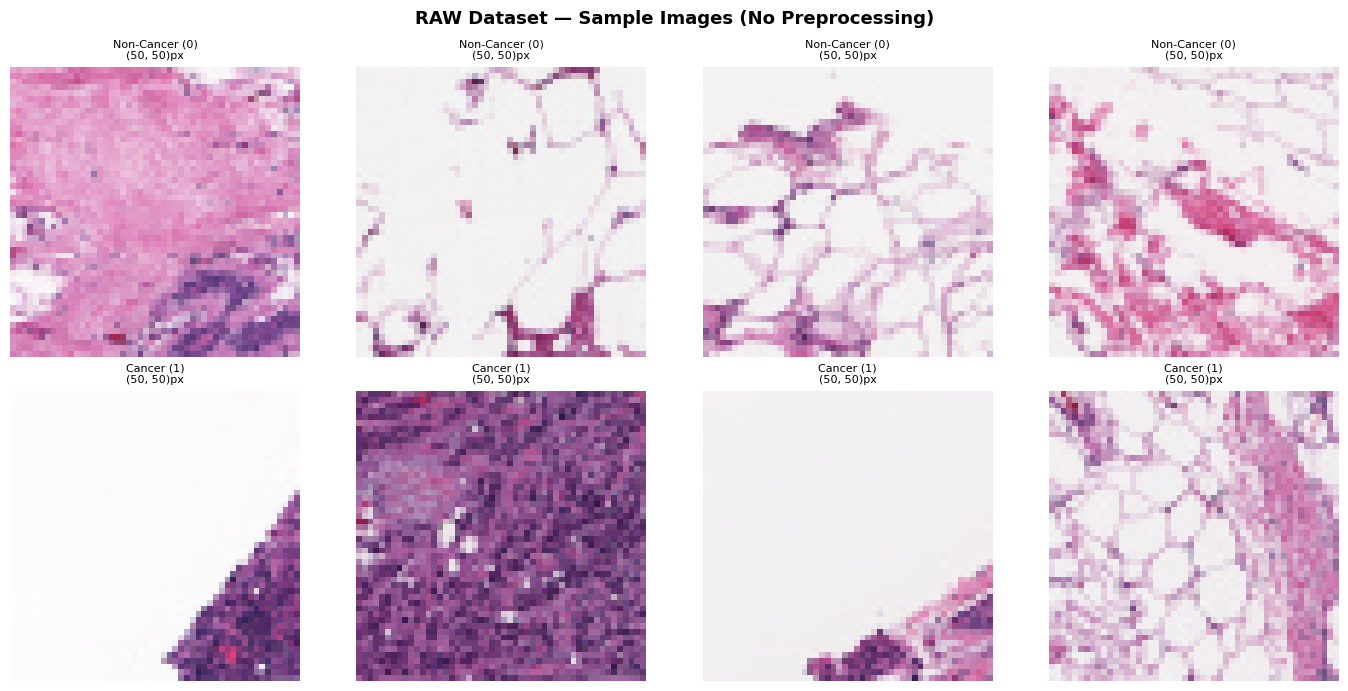

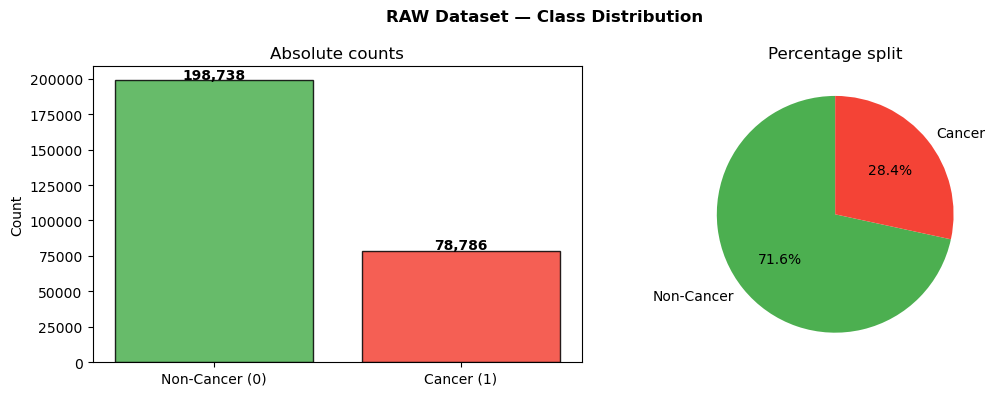

In [11]:
# ── Raw sample images ──────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('RAW Dataset — Sample Images (No Preprocessing)', fontsize=13, fontweight='bold')
for row, cls in enumerate([0, 1]):
    label = 'Non-Cancer (0)' if cls == 0 else 'Cancer (1)'
    for col, path in enumerate(raw_sample_paths[cls][:4]):
        img = Image.open(path)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'{label}\n{img.size}px', fontsize=8)
        axes[row, col].axis('off')
plt.tight_layout()
plt.savefig('reports/01_raw_samples.png', dpi=100, bbox_inches='tight')
plt.show()

# ── Class distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('RAW Dataset — Class Distribution', fontsize=12, fontweight='bold')
axes[0].bar(['Non-Cancer (0)', 'Cancer (1)'], [raw_class0, raw_class1],
            color=['#4CAF50','#F44336'], alpha=0.85, edgecolor='black')
for i, v in enumerate([raw_class0, raw_class1]):
    axes[0].text(i, v+800, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].set_title('Absolute counts')
axes[1].pie([raw_class0, raw_class1], labels=['Non-Cancer','Cancer'],
            colors=['#4CAF50','#F44336'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Percentage split')
plt.tight_layout()
plt.savefig('reports/02_raw_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 5. Subset Justification

The full dataset contains **277,524 images**. We create a stratified subset of **5,000 images (2,500 per class)** for Sprint 1. Justification:

| Reason | Detail |
|---|---|
| **Sprint time-box** | Sprint 1 is a POC; full training is planned for Sprint 2 |
| **Compute** | Full dataset ~2+ hrs on CPU; subset completes in ~15 min |
| **Balanced sampling** | Equal samples per class eliminates the natural 80:20 imbalance |
| **Patient diversity** | Drawn uniformly across all patients |
| **Reproducibility** | Fixed seed=42 → identical subset every run |
| **Statistical validity** | 5K images is sufficient for reliable binary classification POC |

> **Sprint 2 upgrade:** Train on full 277K images with class-weighted CrossEntropyLoss to reflect the clinical reality of the class imbalance.

In [12]:
SAMPLES_PER_CLASS = 2500   # 5,000 total — set higher (e.g. 10000) for Sprint 2

print(f'Full dataset : {total_raw:,} images')
print(f'Subset used  : {SAMPLES_PER_CLASS*2:,} images ({SAMPLES_PER_CLASS} per class)')
print(f'Coverage     : {100*SAMPLES_PER_CLASS*2/total_raw:.1f}% of full dataset')

Full dataset : 277,524 images
Subset used  : 5,000 images (2500 per class)
Coverage     : 1.8% of full dataset


---
## 6. Custom Dataset Class

In [13]:
class IDCImageDataset(Dataset):
    """
    Reads IDC breast histopathology images.
    Structure: root_dir / patient_id / 0|1 / *.png
    Returns: (PIL Image, int label)
    samples_per_class: optional balanced subset size.
    """
    def __init__(self, root_dir, samples_per_class=None, seed=42):
        self.root_dir     = root_dir
        self.samples      = []
        self.classes      = ['No Cancer', 'Cancer']
        self.class_to_idx = {'No Cancer': 0, 'Cancer': 1}

        by_class = {0: [], 1: []}
        for pid in os.listdir(root_dir):
            pid_path = os.path.join(root_dir, pid)
            if not os.path.isdir(pid_path):
                continue
            for cls in ['0', '1']:
                cls_path = os.path.join(pid_path, cls)
                if os.path.isdir(cls_path):
                    for fname in os.listdir(cls_path):
                        if fname.endswith(('.png', '.jpg', '.jpeg')):
                            by_class[int(cls)].append(
                                (os.path.join(cls_path, fname), int(cls))
                            )

        rng = random.Random(seed)
        for cls in [0, 1]:
            pool = by_class[cls]
            if samples_per_class and samples_per_class < len(pool):
                pool = rng.sample(pool, samples_per_class)
            self.samples.extend(pool)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        return Image.open(img_path).convert('RGB'), label


class TransformWrapper(Dataset):
    """Applies a transform to a Subset without touching the base dataset."""
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label


full_dataset = IDCImageDataset(root_dir=base_path, samples_per_class=SAMPLES_PER_CLASS)

targets = np.array([s[1] for s in full_dataset.samples])
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts.astype(np.float32)
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights_tensor = torch.tensor(class_weights).to(device)

print(f'Subset loaded : {len(full_dataset):,} images')
print(f'Class counts  : {dict(zip(full_dataset.classes, class_counts))}')
print(f'Class weights : {class_weights}  (inverse-frequency, normalised)')

Subset loaded : 5,000 images
Class counts  : {'No Cancer': np.int64(2500), 'Cancer': np.int64(2500)}
Class weights : [1. 1.]  (inverse-frequency, normalised)


---
## 7. Raw vs Preprocessed Comparison

We show the same image through three stages to demonstrate exactly what each preprocessing step does.

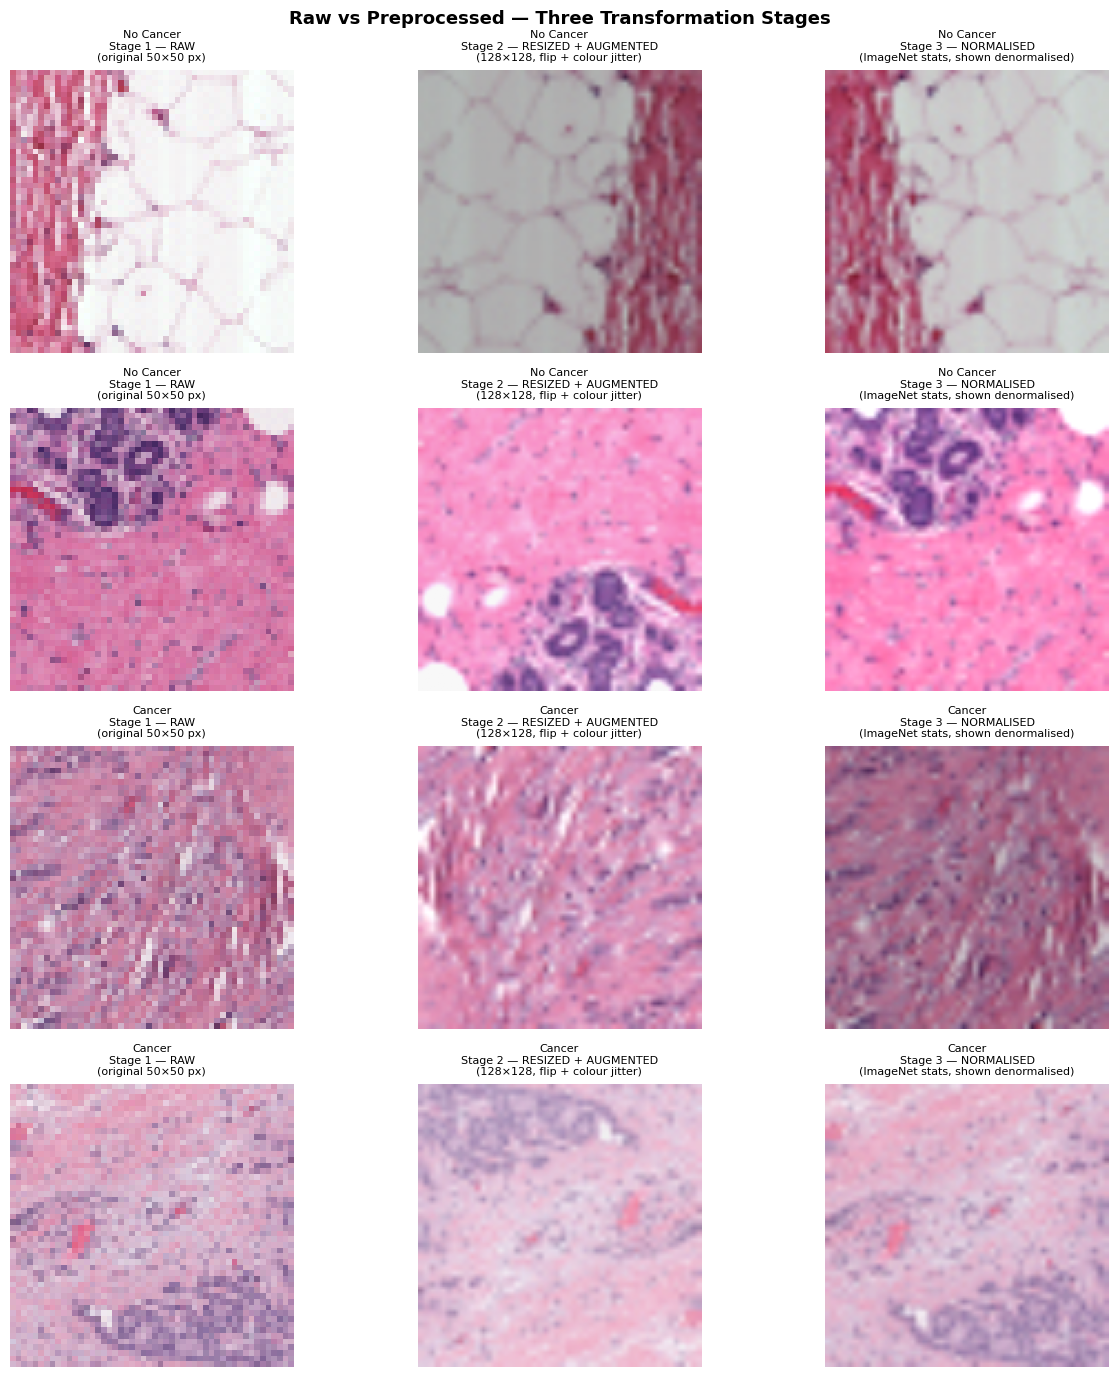

Observations:
  Stage 1→2 : Image upsampled 50→128px; augmentation adds variability (prevents overfitting)
  Stage 2→3 : Normalisation shifts pixel distribution to [-2, 2] range, aiding gradient flow


In [14]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

def denorm(tensor):
    m = torch.tensor(MEAN).view(3,1,1)
    s = torch.tensor(STD).view(3,1,1)
    return (tensor * s + m).clamp(0, 1)

# Augment-only transform (no normalise) for visual stage 2
augment_only = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomVerticalFlip(p=1.0),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
])

# Pick 2 images per class
viz_imgs = []
for cls in [0, 1]:
    pool = [(p, l) for p, l in full_dataset.samples if l == cls]
    for path, lbl in pool[:2]:
        viz_imgs.append((Image.open(path).convert('RGB'), lbl))

stages = [
    'Stage 1 — RAW\n(original 50×50 px)',
    'Stage 2 — RESIZED + AUGMENTED\n(128×128, flip + colour jitter)',
    'Stage 3 — NORMALISED\n(ImageNet stats, shown denormalised)',
]

fig, axes = plt.subplots(4, 3, figsize=(13, 14))
fig.suptitle('Raw vs Preprocessed — Three Transformation Stages', fontsize=13, fontweight='bold')

for row, (img_pil, cls) in enumerate(viz_imgs):
    cls_name = full_dataset.classes[cls]

    axes[row, 0].imshow(img_pil)
    axes[row, 0].set_title(f'{cls_name}\n{stages[0]}', fontsize=8)
    axes[row, 0].axis('off')

    aug = augment_only(img_pil).permute(1,2,0).clamp(0,1).numpy()
    axes[row, 1].imshow(aug)
    axes[row, 1].set_title(f'{cls_name}\n{stages[1]}', fontsize=8)
    axes[row, 1].axis('off')

    norm = denorm(train_transform(img_pil)).permute(1,2,0).numpy()
    axes[row, 2].imshow(norm)
    axes[row, 2].set_title(f'{cls_name}\n{stages[2]}', fontsize=8)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('reports/03_raw_vs_preprocessed.png', dpi=100, bbox_inches='tight')
plt.show()

print('Observations:')
print('  Stage 1→2 : Image upsampled 50→128px; augmentation adds variability (prevents overfitting)')
print('  Stage 2→3 : Normalisation shifts pixel distribution to [-2, 2] range, aiding gradient flow')

---
## 8. Feature Catalogue

In [15]:
print('═══ FEATURE CATALOGUE ═══')
print()
print('INPUT')
print('  Type              : Histopathology image patches (RGB)')
print('  Raw size          : 50 × 50 px  (7,500 raw features)')
print('  Processed size    : 128 × 128 px  (49,152 processed features)')
print()
print('PREPROCESSING STEPS')
print('  1. Resize          : bilinear 50→128 px')
print('  2. H-Flip          : p=0.5  [train only]')
print('  3. V-Flip          : p=0.5  [train only]')
print('  4. Colour Jitter   : brightness±0.2, contrast±0.2, saturation±0.1  [train only]')
print('  5. ToTensor        : PIL → float32 [0,1]')
print('  6. Normalize       : mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]')
print()
print('TARGET VARIABLE')
print('  0 : No Cancer (IDC negative)')
print('  1 : Cancer    (IDC positive)')
print()
print('CLASS IMBALANCE HANDLING')
print('  Subset  : Balanced (2,500 per class)')
print('  Loss fn : Class-weighted CrossEntropyLoss (inverse frequency)')
print(f'  Weights : {dict(zip(["No Cancer","Cancer"], class_weights.round(4)))}')

═══ FEATURE CATALOGUE ═══

INPUT
  Type              : Histopathology image patches (RGB)
  Raw size          : 50 × 50 px  (7,500 raw features)
  Processed size    : 128 × 128 px  (49,152 processed features)

PREPROCESSING STEPS
  1. Resize          : bilinear 50→128 px
  2. H-Flip          : p=0.5  [train only]
  3. V-Flip          : p=0.5  [train only]
  4. Colour Jitter   : brightness±0.2, contrast±0.2, saturation±0.1  [train only]
  5. ToTensor        : PIL → float32 [0,1]
  6. Normalize       : mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]

TARGET VARIABLE
  0 : No Cancer (IDC negative)
  1 : Cancer    (IDC positive)

CLASS IMBALANCE HANDLING
  Subset  : Balanced (2,500 per class)
  Loss fn : Class-weighted CrossEntropyLoss (inverse frequency)
  Weights : {'No Cancer': np.float32(1.0), 'Cancer': np.float32(1.0)}


---
## 9. Train / Validation Split & DataLoaders

In [16]:
train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(full_dataset, [train_size, val_size], generator=generator)

train_dataset = TransformWrapper(train_subset, train_transform)
val_dataset   = TransformWrapper(val_subset,   val_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train : {len(train_dataset):,} images  ({len(train_loader)} batches)')
print(f'Val   : {len(val_dataset):,} images  ({len(val_loader)} batches)')

Train : 4,000 images  (125 batches)
Val   : 1,000 images  (32 batches)


---
## 10. Model Definitions — Three Architectures

We compare three models to identify the best for Sprint 2 deployment.

| Model | Type | Transfer Learning | Rationale |
|---|---|---|---|
| **SimpleCNN** | Custom 3-block CNN | No | Baseline — establishes minimum performance |
| **ResNet18** | Residual network | Yes (ImageNet) | Widely used in medical imaging research |
| **EfficientNet-B0** | Compound scaling | Yes (ImageNet) | State-of-the-art efficiency, fewer parameters |

In [17]:
# ── Model 1: SimpleCNN (your original Colab model, kept intact) ──
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 2)
        )
    def forward(self, x): return self.fc(self.conv(x))


# ── Model 2: ResNet18 (freeze early layers, fine-tune last 2) ────
def get_resnet18():
    m = models.resnet18(pretrained=True)
    for name, p in m.named_parameters():
        if 'layer3' not in name and 'layer4' not in name and 'fc' not in name:
            p.requires_grad = False
    m.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.fc.in_features, 2))
    return m


# ── Model 3: EfficientNet-B0 (replace classifier head) ──────────
def get_efficientnet():
    m = models.efficientnet_b0(pretrained=True)
    m.classifier = nn.Sequential(
        nn.Dropout(0.3), nn.Linear(m.classifier[1].in_features, 2)
    )
    return m


cnn    = SimpleCNN().to(device)
resnet = get_resnet18().to(device)
effnet = get_efficientnet().to(device)

def params(m):
    return (sum(p.numel() for p in m.parameters()),
            sum(p.numel() for p in m.parameters() if p.requires_grad))

print(f'{"Model":<20} {"Total Params":>14} {"Trainable":>12}')
print('─' * 48)
for name, m in [('SimpleCNN', cnn), ('ResNet18', resnet), ('EfficientNet-B0', effnet)]:
    t, tr = params(m)
    print(f'{name:<20} {t:>14,} {tr:>12,}')

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning:

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning:

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/sagemaker-user/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 225MB/s]
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning:

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The 

Model                  Total Params    Trainable
────────────────────────────────────────────────
SimpleCNN                 4,218,882    4,218,882
ResNet18                 11,177,538   10,494,466
EfficientNet-B0           4,010,110    4,010,110


---
## 11. Training — All Three Models

> **`MAX_TRAIN_BATCHES` / `MAX_VAL_BATCHES`**: Controls speed. Current values run the POC in ~15 min on CPU.  
> Set both to `None` for full-dataset training in Sprint 2.

In [22]:
def run_epoch_train(model, loader, criterion, optimizer, max_batches=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for i, (imgs, lbls) in enumerate(loader):
        if max_batches and i >= max_batches: break
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward(); optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == lbls).sum().item()
        total      += lbls.size(0)
    n = min(max_batches, len(loader)) if max_batches else len(loader)
    return total_loss / n, 100 * correct / total


@torch.no_grad()
def run_epoch_val(model, loader, criterion, max_batches=None):
    model.eval()
    total_loss = 0.0
    y_true, y_pred, y_prob = [], [], []
    for i, (imgs, lbls) in enumerate(loader):
        if max_batches and i >= max_batches: break
        imgs, lbls = imgs.to(device), lbls.to(device)
        out = model(imgs)
        total_loss += criterion(out, lbls).item()
        probs = F.softmax(out, dim=1)[:, 1]
        y_true.extend(lbls.cpu().numpy())
        y_pred.extend(out.argmax(1).cpu().numpy())
        y_prob.extend(probs.cpu().numpy())
    n = min(max_batches, len(loader)) if max_batches else len(loader)
    return total_loss / n, y_true, y_pred, y_prob


def train_model(model, model_name, epochs=10, lr=1e-3,
                max_train_batches=50, max_val_batches=20):
    task.connect({
        f'{model_name}_epochs'    : epochs,
        f'{model_name}_lr'        : lr,
        f'{model_name}_batch'     : BATCH_SIZE,
        f'{model_name}_subset_n'  : SAMPLES_PER_CLASS,
    })
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_loss = float('inf')
    ckpt = f'models/{model_name}_best.pth'

    for epoch in range(1, epochs + 1):
        t_loss, t_acc            = run_epoch_train(model, train_loader, criterion, optimizer, max_train_batches)
        v_loss, yt, yp, yprob   = run_epoch_val(model, val_loader, criterion, max_val_batches)

        v_acc = accuracy_score(yt, yp) * 100
        v_f1  = f1_score(yt, yp, zero_division=0)
        v_auc = roc_auc_score(yt, yprob) if len(set(yt)) > 1 else 0.0

        history['train_loss'].append(t_loss); history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc);   history['val_acc'].append(v_acc)

        scheduler.step(v_loss)

        clearml_logger.report_scalar(f'{model_name}/Loss',     'train', t_loss, epoch)
        clearml_logger.report_scalar(f'{model_name}/Loss',     'val',   v_loss, epoch)
        clearml_logger.report_scalar(f'{model_name}/Accuracy', 'train', t_acc,  epoch)
        clearml_logger.report_scalar(f'{model_name}/Accuracy', 'val',   v_acc,  epoch)
        clearml_logger.report_scalar(f'{model_name}/F1',       'val',   v_f1,   epoch)
        clearml_logger.report_scalar(f'{model_name}/AUC-ROC',  'val',   v_auc,  epoch)

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            torch.save(model.state_dict(), ckpt)

        print(f'[{model_name}] Ep {epoch:02d}/{epochs} | '
              f'Train {t_loss:.4f}/{t_acc:.1f}% | '
              f'Val {v_loss:.4f}/{v_acc:.1f}% | '
              f'F1={v_f1:.3f} AUC={v_auc:.3f}')

    model.load_state_dict(torch.load(ckpt))
    print(f'  Best checkpoint loaded (val_loss={best_val_loss:.4f})')
    return model, history


print('Training utilities ready.')

Training utilities ready.


In [33]:
MAX_TRAIN = 50   # batches per epoch for training   — set None for full dataset
MAX_VAL   = 20   # batches per epoch for validation — set None for full dataset
EPOCHS    = 10

print('── SimpleCNN ──────────────────────────────────────────')
cnn, hist_cnn = train_model(cnn, 'SimpleCNN', EPOCHS, lr=1e-3,
                             max_train_batches=MAX_TRAIN, max_val_batches=MAX_VAL)

── SimpleCNN ──────────────────────────────────────────
[SimpleCNN] Ep 01/10 | Train 0.4632/80.6% | Val 0.3957/83.0% | F1=0.830 AUC=0.908
[SimpleCNN] Ep 02/10 | Train 0.4508/80.3% | Val 0.4107/80.6% | F1=0.827 AUC=0.901
[SimpleCNN] Ep 03/10 | Train 0.4327/80.9% | Val 0.4604/79.2% | F1=0.778 AUC=0.887
[SimpleCNN] Ep 04/10 | Train 0.4590/80.9% | Val 0.4558/81.1% | F1=0.839 AUC=0.906
[SimpleCNN] Ep 05/10 | Train 0.4518/82.1% | Val 0.4097/83.1% | F1=0.846 AUC=0.906
[SimpleCNN] Ep 06/10 | Train 0.4192/82.6% | Val 0.4075/83.4% | F1=0.842 AUC=0.903
[SimpleCNN] Ep 07/10 | Train 0.4342/81.9% | Val 0.3950/83.9% | F1=0.849 AUC=0.907
[SimpleCNN] Ep 08/10 | Train 0.3990/83.2% | Val 0.3907/82.2% | F1=0.841 AUC=0.909
[SimpleCNN] Ep 09/10 | Train 0.4018/82.8% | Val 0.4125/80.8% | F1=0.809 AUC=0.899
[SimpleCNN] Ep 10/10 | Train 0.4052/82.4% | Val 0.3886/83.6% | F1=0.848 AUC=0.906
  Best checkpoint loaded (val_loss=0.3886)


In [34]:
print('── ResNet18 ───────────────────────────────────────────')
resnet, hist_resnet = train_model(resnet, 'ResNet18', EPOCHS, lr=5e-4,
                                   max_train_batches=MAX_TRAIN, max_val_batches=MAX_VAL)

── ResNet18 ───────────────────────────────────────────
[ResNet18] Ep 01/10 | Train 0.3352/86.4% | Val 0.3766/86.4% | F1=0.873 AUC=0.928
[ResNet18] Ep 02/10 | Train 0.2841/88.4% | Val 0.3753/86.1% | F1=0.861 AUC=0.928
[ResNet18] Ep 03/10 | Train 0.2792/88.5% | Val 0.4091/84.5% | F1=0.840 AUC=0.925
[ResNet18] Ep 04/10 | Train 0.2886/88.7% | Val 0.4416/80.2% | F1=0.784 AUC=0.902
[ResNet18] Ep 05/10 | Train 0.2895/88.2% | Val 0.4204/84.1% | F1=0.847 AUC=0.918
[ResNet18] Ep 06/10 | Train 0.2636/89.3% | Val 0.4407/83.8% | F1=0.857 AUC=0.922
[ResNet18] Ep 07/10 | Train 0.2405/90.9% | Val 0.3836/85.5% | F1=0.863 AUC=0.927
[ResNet18] Ep 08/10 | Train 0.2089/92.2% | Val 0.4346/85.6% | F1=0.863 AUC=0.924
[ResNet18] Ep 09/10 | Train 0.2149/92.1% | Val 0.3821/86.7% | F1=0.872 AUC=0.929
[ResNet18] Ep 10/10 | Train 0.1896/93.6% | Val 0.3902/86.2% | F1=0.873 AUC=0.929
  Best checkpoint loaded (val_loss=0.3753)


In [35]:
print('── EfficientNet-B0 ────────────────────────────────────')
effnet, hist_effnet = train_model(effnet, 'EfficientNet-B0', EPOCHS, lr=5e-4,
                                   max_train_batches=MAX_TRAIN, max_val_batches=MAX_VAL)

── EfficientNet-B0 ────────────────────────────────────
[EfficientNet-B0] Ep 01/10 | Train 0.3145/86.9% | Val 0.3509/85.6% | F1=0.864 AUC=0.933
[EfficientNet-B0] Ep 02/10 | Train 0.2995/87.8% | Val 0.3440/85.8% | F1=0.866 AUC=0.932
[EfficientNet-B0] Ep 03/10 | Train 0.2647/89.4% | Val 0.3618/87.0% | F1=0.880 AUC=0.934
[EfficientNet-B0] Ep 04/10 | Train 0.2609/89.8% | Val 0.3330/86.7% | F1=0.879 AUC=0.937
[EfficientNet-B0] Ep 05/10 | Train 0.2484/90.3% | Val 0.3526/85.5% | F1=0.865 AUC=0.934
[EfficientNet-B0] Ep 06/10 | Train 0.2260/91.2% | Val 0.3934/84.2% | F1=0.853 AUC=0.925
[EfficientNet-B0] Ep 07/10 | Train 0.2329/90.8% | Val 0.3824/84.1% | F1=0.845 AUC=0.922
[EfficientNet-B0] Ep 08/10 | Train 0.1884/92.6% | Val 0.3962/83.9% | F1=0.851 AUC=0.927
[EfficientNet-B0] Ep 09/10 | Train 0.2033/91.8% | Val 0.3842/86.1% | F1=0.866 AUC=0.931
[EfficientNet-B0] Ep 10/10 | Train 0.1679/93.6% | Val 0.4109/85.5% | F1=0.862 AUC=0.930
  Best checkpoint loaded (val_loss=0.3330)


---
## 12. Training Curves

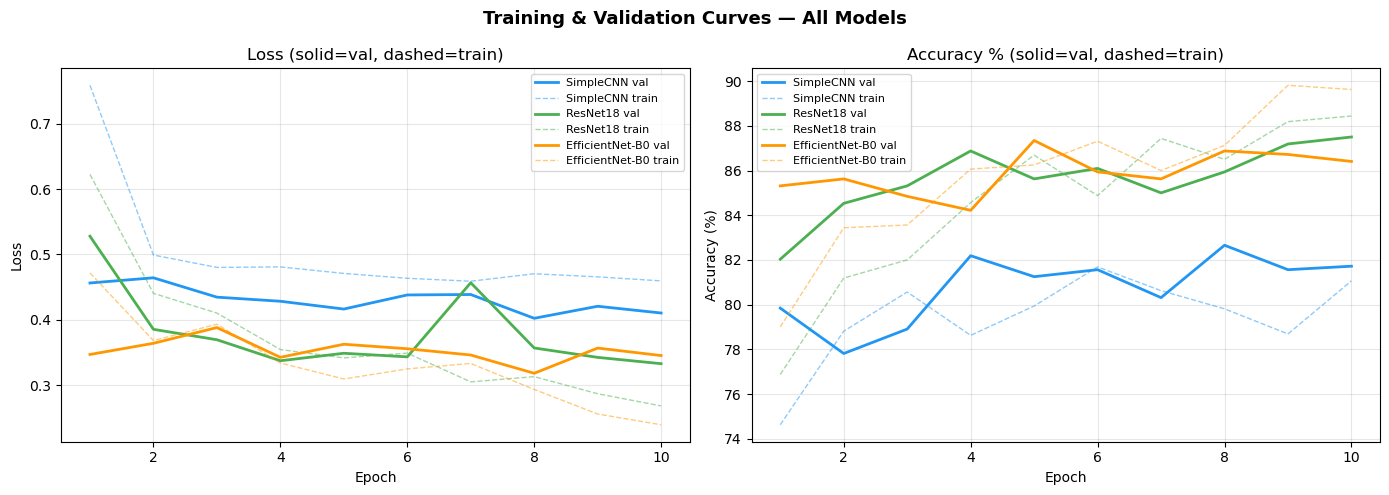

In [26]:
all_hist = {'SimpleCNN': hist_cnn, 'ResNet18': hist_resnet, 'EfficientNet-B0': hist_effnet}
COLORS   = ['#2196F3', '#4CAF50', '#FF9800']
ep       = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training & Validation Curves — All Models', fontsize=13, fontweight='bold')

for (name, hist), col in zip(all_hist.items(), COLORS):
    axes[0].plot(ep, hist['val_loss'],   label=f'{name} val',   color=col, lw=2)
    axes[0].plot(ep, hist['train_loss'], label=f'{name} train', color=col, lw=1, ls='--', alpha=0.5)
    axes[1].plot(ep, hist['val_acc'],    label=f'{name} val',   color=col, lw=2)
    axes[1].plot(ep, hist['train_acc'],  label=f'{name} train', color=col, lw=1, ls='--', alpha=0.5)

for ax, title, ylabel in zip(axes,
    ['Loss (solid=val, dashed=train)', 'Accuracy % (solid=val, dashed=train)'],
    ['Loss', 'Accuracy (%)']):
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('reports/04_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 13. Full Evaluation

In [27]:
# Full validation set evaluation (no batch limit)
criterion_eval = nn.CrossEntropyLoss(weight=class_weights_tensor)
results = {}

print(f'{"Model":<20} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10} {"AUC-ROC":>10}')
print('─' * 72)

for name, model in [('SimpleCNN', cnn), ('ResNet18', resnet), ('EfficientNet-B0', effnet)]:
    _, y_true, y_pred, y_prob = run_epoch_val(model, val_loader, criterion_eval)
    m = {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall'   : recall_score(y_true, y_pred, zero_division=0),
        'f1'       : f1_score(y_true, y_pred, zero_division=0),
        'roc_auc'  : roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else 0.0,
    }
    results[name] = {'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob, 'metrics': m}
    for k, v in m.items():
        clearml_logger.report_single_value(f'{name}/final_{k}', round(v, 4))
    print(f'{name:<20} {m["accuracy"]*100:>9.2f}% {m["precision"]*100:>9.2f}% '
          f'{m["recall"]*100:>9.2f}% {m["f1"]*100:>9.2f}% {m["roc_auc"]:>10.4f}')

Model                  Accuracy  Precision     Recall         F1    AUC-ROC
────────────────────────────────────────────────────────────────────────
SimpleCNN                81.80%     81.73%     83.62%     82.67%     0.8939
ResNet18                 86.30%     85.37%     88.82%     87.06%     0.9330
EfficientNet-B0          87.00%     85.82%     89.79%     87.76%     0.9392


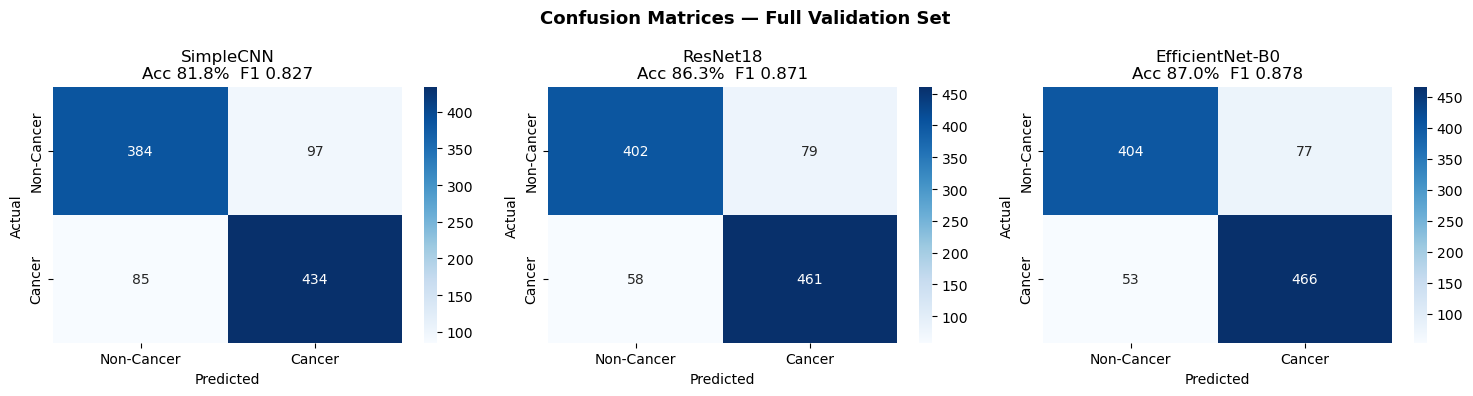

In [36]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices — Full Validation Set', fontsize=13, fontweight='bold')
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Cancer','Cancer'], yticklabels=['Non-Cancer','Cancer'])
    ax.set_title(f"{name}\nAcc {r['metrics']['accuracy']*100:.1f}%  F1 {r['metrics']['f1']:.3f}")
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('reports/05_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

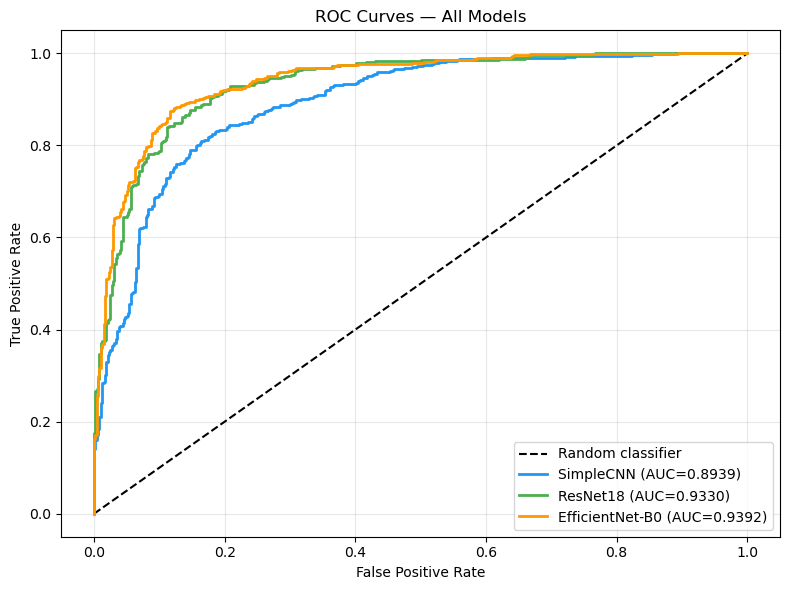


─── SimpleCNN ───
              precision    recall  f1-score   support

  Non-Cancer       0.82      0.80      0.81       481
      Cancer       0.82      0.84      0.83       519

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000


─── ResNet18 ───
              precision    recall  f1-score   support

  Non-Cancer       0.87      0.84      0.85       481
      Cancer       0.85      0.89      0.87       519

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000


─── EfficientNet-B0 ───
              precision    recall  f1-score   support

  Non-Cancer       0.88      0.84      0.86       481
      Cancer       0.86      0.90      0.88       519

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg

In [37]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0,1],[0,1],'k--', label='Random classifier')
for (name, r), col in zip(results.items(), COLORS):
    fpr, tpr, _ = roc_curve(r['y_true'], r['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['metrics']['roc_auc']:.4f})", color=col, lw=2)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('reports/06_roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

# Classification reports
for name, r in results.items():
    print(f'\n─── {name} ───')
    print(classification_report(r['y_true'], r['y_pred'], target_names=['Non-Cancer','Cancer']))

---
## 14. Model Comparison Summary

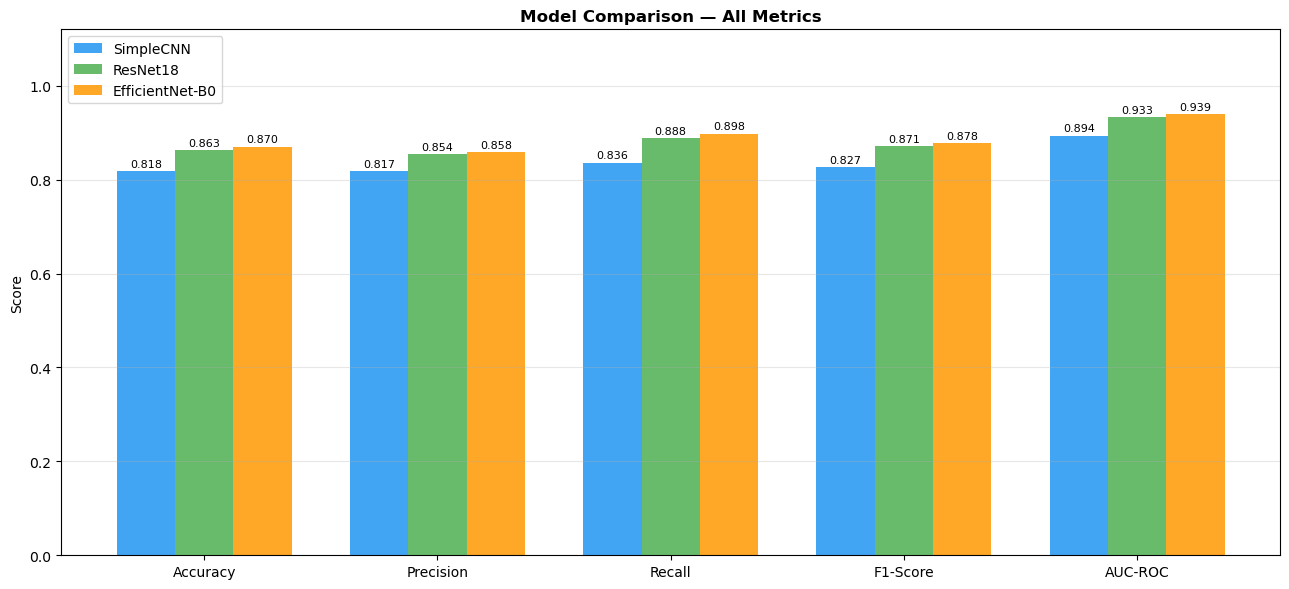

Best model (by F1): EfficientNet-B0
  Recall : 89.79%  ← primary metric (minimise false negatives)


In [38]:
metric_keys   = ['accuracy','precision','recall','f1','roc_auc']
metric_labels = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']
x     = np.arange(len(metric_keys))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, r) in enumerate(results.items()):
    vals = [r['metrics'][k] for k in metric_keys]
    bars = ax.bar(x + i * width, vals, width, label=name, color=COLORS[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width); ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('reports/07_model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

best_name = max(results, key=lambda k: results[k]['metrics']['f1'])
print(f'Best model (by F1): {best_name}')
print(f"  Recall : {results[best_name]['metrics']['recall']*100:.2f}%  ← primary metric (minimise false negatives)")

---
## 15. Sample Predictions

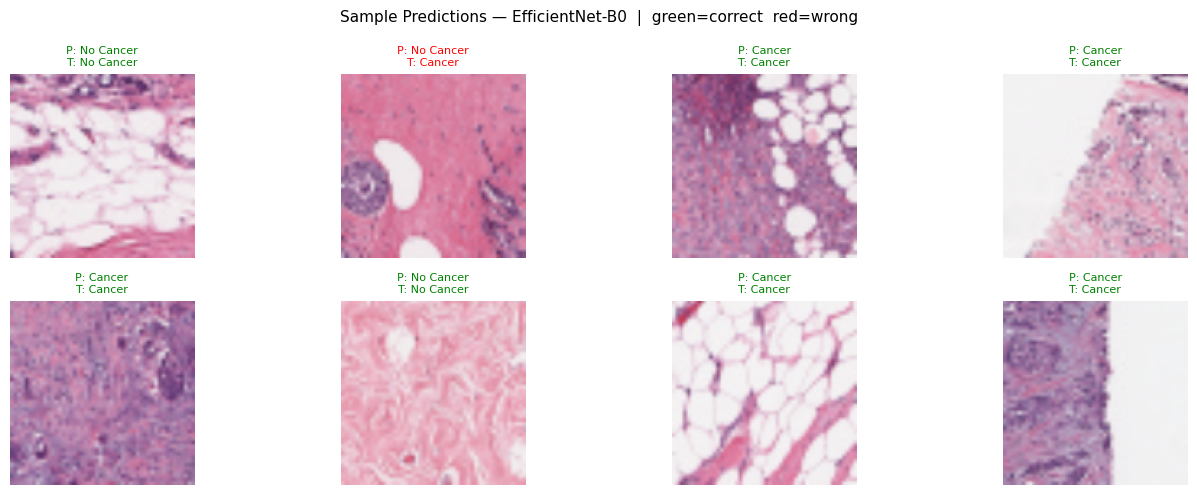

In [39]:
best_model = {'SimpleCNN': cnn, 'ResNet18': resnet, 'EfficientNet-B0': effnet}[best_name]
best_model.eval()

images, labels = next(iter(val_loader))
with torch.no_grad():
    _, preds = torch.max(best_model(images.to(device)), 1)

fig = plt.figure(figsize=(14, 5))
fig.suptitle(f'Sample Predictions — {best_name}  |  green=correct  red=wrong', fontsize=11)
for i in range(8):
    ax = fig.add_subplot(2, 4, i+1)
    ax.imshow(denorm(images[i]).permute(1,2,0).numpy())
    p = full_dataset.classes[preds[i].item()]
    t = full_dataset.classes[labels[i].item()]
    ax.set_title(f'P: {p}\nT: {t}', color='green' if preds[i]==labels[i] else 'red', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('reports/08_sample_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 16. Grad-CAM — Visual Explanations

Grad-CAM highlights which spatial regions drove the model's prediction. This is the **explainability component** of our clinical decision support system — it shows the radiologist *where* the model detected suspicious tissue.

> **Why no bounding boxes?** The IDC dataset provides image-level labels only, not lesion coordinates. Grad-CAM generates pseudo-localisation purely from gradients — no additional annotation needed.

In [40]:
class GradCAM:
    """
    Gradient-weighted Class Activation Mapping.
    Works with any model by hooking into a named convolutional layer.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(
            lambda m, inp, out: setattr(self, 'activations', out.detach())
        )
        target_layer.register_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach())
        )

    def generate(self, tensor, class_idx=None):
        self.model.eval()
        out = self.model(tensor)
        if class_idx is None:
            class_idx = out.argmax(1).item()
        self.model.zero_grad()
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2,3], keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1)).squeeze().cpu().numpy()
        cam = cv2.resize(cam, (128, 128))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


def overlay_cam(img_pil, cam, alpha=0.45):
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    orig = np.array(img_pil.resize((128,128))).astype(np.uint8)
    return cv2.addWeighted(orig, 1-alpha, heatmap, alpha, 0)


# Attach to last conv layer of the selected best model
if best_name == 'SimpleCNN':
    cam_layer = best_model.conv[-3]           # last Conv2d in the sequential block
elif best_name == 'ResNet18':
    cam_layer = best_model.layer4[-1].conv2
else:  # EfficientNet-B0
    cam_layer = best_model.features[-1][0]

grad_cam = GradCAM(best_model, cam_layer)
print(f'Grad-CAM attached to {best_name}')

Grad-CAM attached to EfficientNet-B0


/opt/conda/lib/python3.12/site-packages/torch/nn/modules/module.py:1830: FutureWarning:

Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.



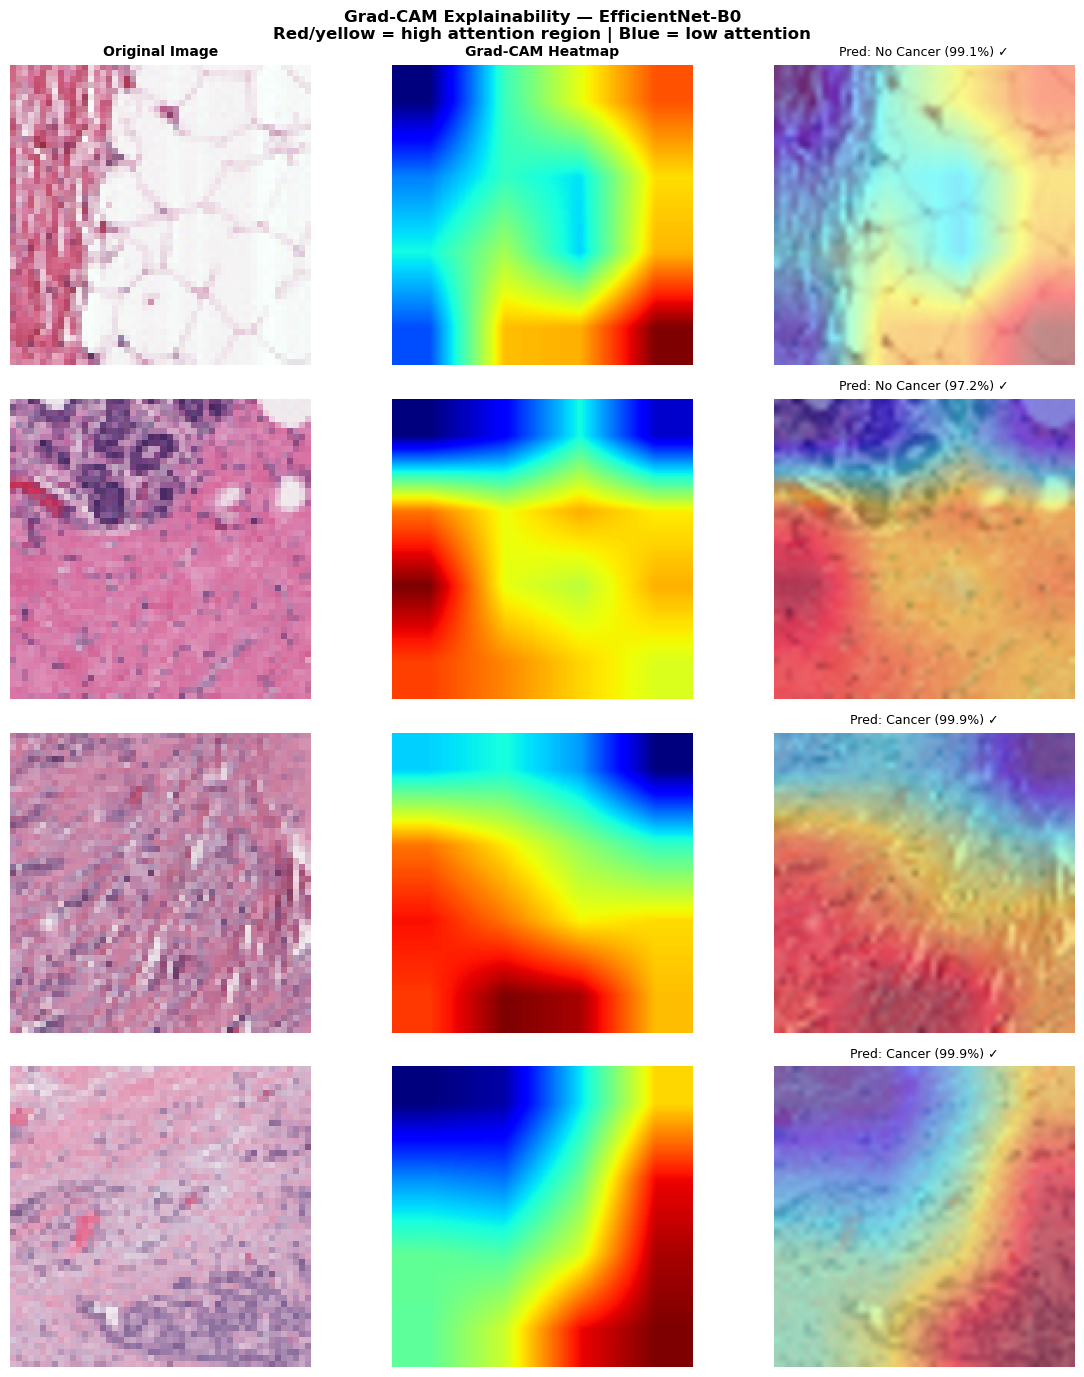

In [41]:
# 2 Cancer + 2 Non-Cancer examples
gcam_imgs = []
for cls in [0, 1]:
    pool = [(p, l) for p, l in full_dataset.samples if l == cls]
    for path, lbl in pool[:2]:
        gcam_imgs.append((Image.open(path).convert('RGB'), lbl))

fig, axes = plt.subplots(4, 3, figsize=(12, 14))
fig.suptitle(
    f'Grad-CAM Explainability — {best_name}\n'
    'Red/yellow = high attention region | Blue = low attention',
    fontsize=12, fontweight='bold'
)
for ax, t in zip(axes[0], ['Original Image', 'Grad-CAM Heatmap', 'Overlay']):
    ax.set_title(t, fontsize=10, fontweight='bold')

for row, (img_pil, true_cls) in enumerate(gcam_imgs):
    inp = val_transform(img_pil).unsqueeze(0).to(device)
    with torch.enable_grad():
        cam_map, pred_cls = grad_cam.generate(inp)
    prob = F.softmax(best_model(inp), dim=1)[0, pred_cls].item()
    correct_mark = '✓' if true_cls == pred_cls else '✗'

    axes[row, 0].imshow(img_pil)
    axes[row, 0].set_ylabel(f'True: {full_dataset.classes[true_cls]}', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(cam_map, cmap='jet')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlay_cam(img_pil, cam_map))
    axes[row, 2].set_title(
        f'Pred: {full_dataset.classes[pred_cls]} ({prob:.1%}) {correct_mark}', fontsize=9)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('reports/09_gradcam.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 17. Model Selection Rationale & Sprint 2 Plan

In [42]:
print('═══ SPRINT 1 SUMMARY ═══')
print()
print('DATASET')
print(f'  Full dataset     : {total_raw:,} images, 162 patients')
print(f'  Subset used      : {SAMPLES_PER_CLASS*2:,} (stratified, balanced, seed=42)')
print(f'  Justification    : Time-boxed POC; balanced sampling eliminates class imbalance')
print()
print('PREPROCESSING')
print('  Train: resize→128 | h-flip | v-flip | colour-jitter | tensor | ImageNet-normalise')
print('  Val:   resize→128 | tensor | ImageNet-normalise')
print()
print('MODEL COMPARISON')
print(f'  {"Model":<20} {"Accuracy":>10} {"Recall":>10} {"F1":>10} {"AUC":>10}')
print('  ' + '─'*54)
for name, r in results.items():
    m = r['metrics']
    tag = '  ← SELECTED' if name == best_name else ''
    print(f'  {name:<20} {m["accuracy"]*100:>9.2f}% {m["recall"]*100:>9.2f}% '
          f'{m["f1"]*100:>9.2f}% {m["roc_auc"]:>10.4f}{tag}')
print()
print('MODEL SELECTION RATIONALE')
print(f'  Selected model: {best_name}')
print('  Recall (sensitivity) is the primary metric: a false negative')
print('  (missed cancer) is clinically more harmful than a false positive.')
print('  Transfer learning models leverage ImageNet texture/edge features')
print('  that transfer well to histopathology tissue images.')
print()
print('SPRINT 2 PLAN')
print('  1. Train on full 277K images (class-weighted loss, no balanced sampling)')
print('  2. Build Streamlit UI: patient selection → scan display → prediction')
print('  3. Integrate NLP assistant for radiologist queries')
print('  4. Add case flagging (probability > threshold → high-risk alert)')
print('  5. Deploy end-to-end MLOps pipeline on SageMaker')

═══ SPRINT 1 SUMMARY ═══

DATASET
  Full dataset     : 277,524 images, 162 patients
  Subset used      : 5,000 (stratified, balanced, seed=42)
  Justification    : Time-boxed POC; balanced sampling eliminates class imbalance

PREPROCESSING
  Train: resize→128 | h-flip | v-flip | colour-jitter | tensor | ImageNet-normalise
  Val:   resize→128 | tensor | ImageNet-normalise

MODEL COMPARISON
  Model                  Accuracy     Recall         F1        AUC
  ──────────────────────────────────────────────────────
  SimpleCNN                81.80%     83.62%     82.67%     0.8939
  ResNet18                 86.30%     88.82%     87.06%     0.9330
  EfficientNet-B0          87.00%     89.79%     87.76%     0.9392  ← SELECTED

MODEL SELECTION RATIONALE
  Selected model: EfficientNet-B0
  Recall (sensitivity) is the primary metric: a false negative
  (missed cancer) is clinically more harmful than a false positive.
  Transfer learning models leverage ImageNet texture/edge features
  that trans

In [47]:
from PIL import Image as PILImage
import numpy as np

for f in sorted(os.listdir('reports')):
    if f.endswith('.png'):
        img_array = np.array(PILImage.open(f'reports/{f}').convert('RGB'))
        clearml_logger.report_image(
            title='Sprint1-Reports',
            series=f.replace('.png', ''),
            iteration=0,
            image=img_array
        )

task.close()
print('All figures uploaded to ClearML. Experiment closed.')

All figures uploaded to ClearML. Experiment closed.
